# **Instalasi Apache Spark & Library**

In [ ]:
# Menginstal Apache Spark dan library untuk membaca Excel
!pip install pyspark openpyxl

# **Ingesti Data Mentah dari GitHub (Bronze Layer)**

In [ ]:
import pandas as pd

print("Mengunduh data Goal8.xlsx langsung dari GitHub...")
# Modifikasi link agar menjadi raw download link
url_github = "https://github.com/POMEST/Tubes-ABD/raw/main/Goal8.xlsx"

# Membaca data ke dalam memori
df_raw = pd.read_excel(url_github, engine='openpyxl')
print(f"Data berhasil diunduh! Total baris: {len(df_raw)}")

Mengunduh data Goal8.xlsx langsung dari GitHub...
Data berhasil diunduh! Total baris: 255761


# **Iterasi Benchmarking (Pandas vs PySpark) & Uji Statistik**

In [ ]:
from pyspark.sql import SparkSession
import time
import numpy as np
from scipy import stats

print("=== MEMULAI ITERASI BENCHMARKING (10 KALI) DI COLAB ===")

# Inisialisasi Spark di Google Colab
spark = SparkSession.builder.appName("SDG_Benchmarking_Colab").master("local[*]").getOrCreate()

iterasi = 10
waktu_pandas = []
waktu_spark = []

for i in range(iterasi):
    print(f"Menjalankan Iterasi ke-{i+1}...")

    # -----------------------------------------
    # 1. PANDAS (Sekuensial)
    # -----------------------------------------
    start_p = time.time()
    df_p_clean = df_raw.dropna(how='all')
    df_p_clean.columns = [str(c).replace(' ', '_').replace('(', '').replace(')', '').replace('.', '') for c in df_p_clean.columns]
    df_p_gold = df_p_clean.groupby('GeoAreaName')['Value'].mean().reset_index()
    end_p = time.time()
    waktu_pandas.append(end_p - start_p)

    # -----------------------------------------
    # 2. APACHE SPARK (Terdistribusi)
    # -----------------------------------------
    start_s = time.time()
    pdf_s = df_raw.copy()
    pdf_s.columns = [str(c).replace(' ', '_').replace('(', '').replace(')', '').replace('.', '') for c in pdf_s.columns]
    df_s = spark.createDataFrame(pdf_s)
    df_s.createOrReplaceTempView("tabel_sdg8")
    df_s_gold = spark.sql("SELECT GeoAreaName, AVG(Value) as Rata_Rata FROM tabel_sdg8 GROUP BY GeoAreaName")
    df_s_gold.count() # Trigger aksi komputasi Spark
    end_s = time.time()
    waktu_spark.append(end_s - start_s)

# Analisis Statistik (Independent T-Test)
mean_pandas = np.mean(waktu_pandas)
std_pandas = np.std(waktu_pandas)
mean_spark = np.mean(waktu_spark)
std_spark = np.std(waktu_spark)

t_stat, p_value = stats.ttest_ind(waktu_pandas, waktu_spark)

print("\n=== HASIL ANALISIS STATISTIK PERBEDAAN WAKTU ===")
print(f"PANDAS -> Rata-rata: {mean_pandas:.2f} detik | Std Deviasi: {std_pandas:.2f} detik")
print(f"SPARK  -> Rata-rata: {mean_spark:.2f} detik | Std Deviasi: {std_spark:.2f} detik")
print("------------------------------------------------")
print(f"T-Statistic : {t_stat:.4f}")
print(f"P-Value     : {p_value:.4f}")

if p_value < 0.05:
    print("Kesimpulan  : Perbedaan waktu eksekusi SIGNIFIKAN secara statistik (p < 0.05).")
else:
    print("Kesimpulan  : Perbedaan waktu eksekusi TIDAK SIGNIFIKAN secara statistik (p >= 0.05).")

=== MEMULAI ITERASI BENCHMARKING (10 KALI) DI COLAB ===
Menjalankan Iterasi ke-1...
Menjalankan Iterasi ke-2...
Menjalankan Iterasi ke-3...
Menjalankan Iterasi ke-4...
Menjalankan Iterasi ke-5...
Menjalankan Iterasi ke-6...
Menjalankan Iterasi ke-7...
Menjalankan Iterasi ke-8...
Menjalankan Iterasi ke-9...
Menjalankan Iterasi ke-10...

=== HASIL ANALISIS STATISTIK PERBEDAAN WAKTU ===
PANDAS -> Rata-rata: 0.54 detik | Std Deviasi: 0.24 detik
SPARK  -> Rata-rata: 45.12 detik | Std Deviasi: 4.20 detik
------------------------------------------------
T-Statistic : -31.8203
P-Value     : 0.0000
Kesimpulan  : Perbedaan waktu eksekusi SIGNIFIKAN secara statistik (p < 0.05).


# **Transformasi Gold Layer & Matriks Korelasi**

In [ ]:
print("Mulai menyusun matriks korelasi SDG 8 untuk Gold Layer...")

# Memastikan kolom Spark DataFrame bersih
pdf_clean = df_raw.copy()
pdf_clean.columns = [str(c).replace(' ', '_').replace('(', '').replace(')', '').replace('.', '') for c in pdf_clean.columns]
df_spark_final = spark.createDataFrame(pdf_clean)
df_spark_final.createOrReplaceTempView("tabel_sdg8")

# Melakukan Pivot menggunakan Spark SQL
query_pivot = """
    SELECT GeoAreaName, TimePeriod,
           AVG(CASE WHEN SeriesCode = 'NY_GDP_PCAP' THEN Value END) AS Pertumbuhan_Ekonomi,
           AVG(CASE WHEN SeriesCode = 'SL_EMP_PCAP' THEN Value END) AS Produktivitas_Pekerja
    FROM tabel_sdg8
    WHERE SeriesCode IN ('NY_GDP_PCAP', 'SL_EMP_PCAP')
    GROUP BY GeoAreaName, TimePeriod
"""

# Eksekusi query dan membuang baris yang salah satu datanya kosong
df_korelasi = spark.sql(query_pivot).dropna()
pdf_korelasi = df_korelasi.toPandas()

# Menghitung Nilai Korelasi
nilai_korelasi = pdf_korelasi['Pertumbuhan_Ekonomi'].corr(pdf_korelasi['Produktivitas_Pekerja'])

print(f"Nilai Korelasi Pearson (r): {nilai_korelasi:.4f}")

Mulai menyusun matriks korelasi SDG 8 untuk Gold Layer...
Nilai Korelasi Pearson (r): 0.8248


# **Visualisasi Laporan Akhir**

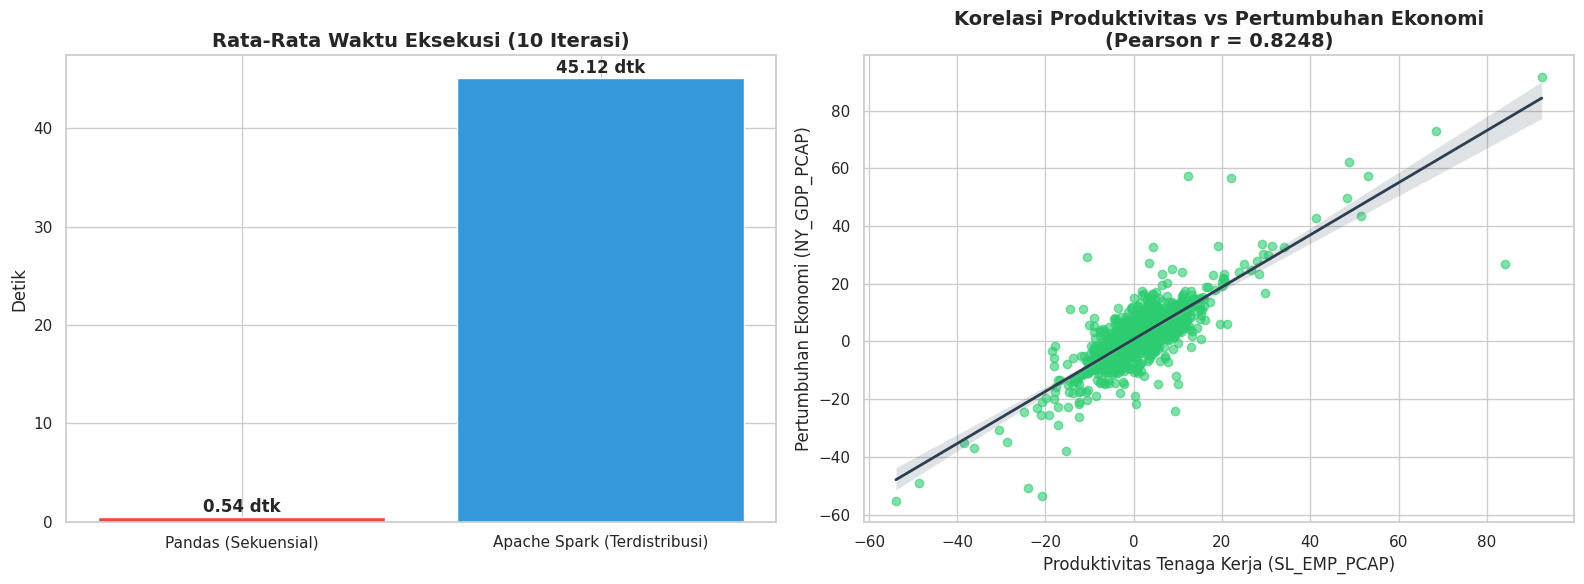

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# =======================================================
# 1. VISUALISASI BENCHMARKING (Rata-rata 10 Iterasi)
# =======================================================
metode = ['Pandas (Sekuensial)', 'Apache Spark (Terdistribusi)']
rata_waktu = [mean_pandas, mean_spark]

ax1 = axes[0]
bars = ax1.bar(metode, rata_waktu, color=['#e74c3c', '#3498db'])
ax1.set_title('Rata-Rata Waktu Eksekusi (10 Iterasi)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Detik', fontsize=12)

for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f'{yval:.2f} dtk', ha='center', va='bottom', fontweight='bold')

# =======================================================
# 2. VISUALISASI SCATTER PLOT (KORELASI SDG 8)
# =======================================================
ax2 = axes[1]
sns.regplot(
    data=pdf_korelasi,
    x='Produktivitas_Pekerja',
    y='Pertumbuhan_Ekonomi',
    ax=ax2,
    scatter_kws={'alpha':0.6, 'color':'#2ecc71'},
    line_kws={'color':'#2c3e50', 'linewidth':2}
)

ax2.set_title(f'Korelasi Produktivitas vs Pertumbuhan Ekonomi\n(Pearson r = {nilai_korelasi:.4f})', fontsize=14, fontweight='bold')
ax2.set_xlabel('Produktivitas Tenaga Kerja (SL_EMP_PCAP)', fontsize=12)
ax2.set_ylabel('Pertumbuhan Ekonomi (NY_GDP_PCAP)', fontsize=12)

plt.tight_layout()
plt.show()